Starting Adam Optimization...
Epoch     0 | Total: 6.1493e+01 | PDE: 6.1492e+01 | BC: 6.5687e-05 | Pen: 0.0000e+00
Epoch  1000 | Total: 1.5993e+00 | PDE: 1.5879e+00 | BC: 1.0848e-03 | Pen: 5.6789e-08
Epoch  2000 | Total: 2.9586e-01 | PDE: 2.9261e-01 | BC: 3.2503e-04 | Pen: 7.5274e-10
Epoch  3000 | Total: 1.2447e-02 | PDE: 1.1723e-02 | BC: 6.9776e-05 | Pen: 2.6551e-09
Epoch  4000 | Total: 6.6347e-03 | PDE: 6.4612e-03 | BC: 1.7159e-05 | Pen: 1.8373e-10
Epoch  5000 | Total: 5.5326e-03 | PDE: 5.4671e-03 | BC: 6.5435e-06 | Pen: 8.5648e-12
Epoch  6000 | Total: 5.3908e-03 | PDE: 5.3564e-03 | BC: 3.4418e-06 | Pen: 0.0000e+00
Epoch  7000 | Total: 4.9469e-03 | PDE: 4.9299e-03 | BC: 1.6979e-06 | Pen: 0.0000e+00
Epoch  8000 | Total: 4.8277e-03 | PDE: 4.8176e-03 | BC: 1.0027e-06 | Pen: 0.0000e+00
Epoch  9000 | Total: 4.7728e-03 | PDE: 4.7634e-03 | BC: 9.4076e-07 | Pen: 0.0000e+00
Epoch 10000 | Total: 4.6909e-03 | PDE: 4.6840e-03 | BC: 6.8693e-07 | Pen: 0.0000e+00
Epoch 11000 | Total: 4.6465e-03 | P

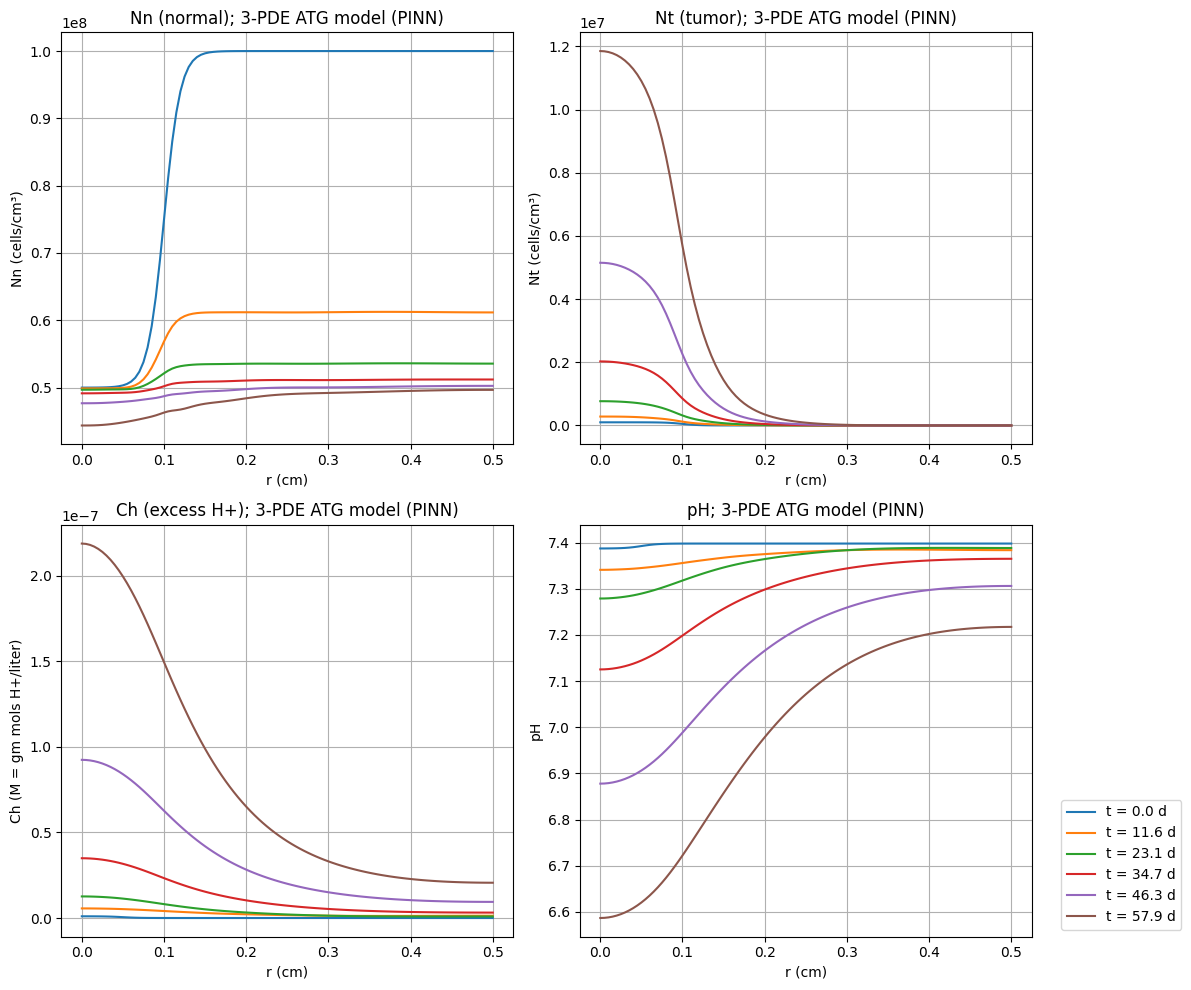

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. Configuration & Hyperparameters
# ==========================================
R_MAX = 0.5
T_MAX = 5.0e6

N_F = 25000        
N_BC = 2000        
EPOCHS_ADAM = 15000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L_N1 = 5.0
L_N2 = 50.0
L_T1 = 5.0
L_DT = 0.004
L_HT = 1.0 / 550.0
L_DH = 5.0 / 27.5

KN = 5.0e7
KT = 5.0e7
CH_REF = 1.0e-5

# ==========================================
# 2. Physics-Informed Neural Network
# ==========================================
class TumorGrowthPINN(nn.Module):
    def __init__(self):
        super(TumorGrowthPINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 3) 
        )

    def forward(self, rho, tau):
        x = torch.cat([rho, tau], dim=1)
        out = self.net(x)
        
        r = rho * R_MAX
        
        tanhr_nn_nt = torch.tanh(50.0 * (r - 0.1))
        tanhr_ch = torch.tanh(50.0 * (r - 0.05))
        
        nn_ic = 1.0 * (1.0 - tanhr_nn_nt) / 2.0 + 2.0 * (1.0 + tanhr_nn_nt) / 2.0
        nt_ic = 0.002 * (1.0 - tanhr_nn_nt) / 2.0 + 0.00002 * (1.0 + tanhr_nn_nt) / 2.0
        ch_ic = 1.0e-4 * (1.0 - tanhr_ch) / 2.0
        
        nn_val = nn_ic + tau * out[:, 0:1]
        nt_val = nt_ic + tau * out[:, 1:2] * 0.25
        ch_val = ch_ic + tau * out[:, 2:3] * 0.02
        
        return nn_val, nt_val, ch_val

def compute_gradients(y, x):
    return torch.autograd.grad(
        y, x, 
        grad_outputs=torch.ones_like(y),
        create_graph=True, 
        retain_graph=True
    )[0]

# ==========================================
# 3. Loss Functions
# ==========================================
def pde_loss(model, rho, tau):
    rho.requires_grad_(True)
    tau.requires_grad_(True)
    
    nn_val, nt_val, ch_val = model(rho, tau)
    
    dnn_dtau = compute_gradients(nn_val, tau)
    dnt_dtau = compute_gradients(nt_val, tau)
    dch_dtau = compute_gradients(ch_val, tau)
    
    dnn_drho = compute_gradients(nn_val, rho)
    dnt_drho = compute_gradients(nt_val, rho)
    dch_drho = compute_gradients(ch_val, rho)
    
    d2nt_drho2 = compute_gradients(dnt_drho, rho)
    d2ch_drho2 = compute_gradients(dch_drho, rho)
    
    # -- Eq 1: Normal Cells --
    res_nn = dnn_dtau - L_N1 * nn_val * (1.0 - nn_val) + L_N2 * ch_val * nn_val
    
    # -- Eq 2: Tumor Cells --
    D_term = torch.nn.functional.softplus(1.0 - nn_val, beta=20.0)
    dD_drho = compute_gradients(D_term, rho)
    
    safe_rho = torch.clamp(rho, min=1e-6)
    lap_nt = torch.where(rho < 1e-4, 3.0 * d2nt_drho2, d2nt_drho2 + 2.0 * dnt_drho / safe_rho)
    
    res_nt = dnt_dtau - L_T1 * nt_val * (1.0 - nt_val) - L_DT * (D_term * lap_nt + dD_drho * dnt_drho)
    
    # -- Eq 3: H+ Concentration --
    lap_ch = torch.where(rho < 1e-4, 3.0 * d2ch_drho2, d2ch_drho2 + 2.0 * dch_drho / safe_rho)
    res_ch = L_HT * dch_dtau - (nt_val - ch_val) - L_DH * lap_ch
    
    loss_nn = torch.mean((res_nn)**2)
    loss_nt = torch.mean((res_nt * 20.0)**2)
    loss_ch = torch.mean((res_ch * 20.0)**2)
    
    pen_nn = torch.mean(torch.relu(-nn_val)**2)
    pen_nt = torch.mean(torch.relu(-nt_val)**2)
    pen_ch = torch.mean(torch.relu(-ch_val)**2)
    
    return loss_nn + loss_nt + loss_ch, pen_nn + pen_nt + pen_ch

def bc_loss(model, tau_bc):
    rho_0 = torch.zeros_like(tau_bc, requires_grad=True).to(DEVICE)
    rho_1 = torch.ones_like(tau_bc, requires_grad=True).to(DEVICE)
    
    nn_0, nt_0, ch_0 = model(rho_0, tau_bc)
    dnn_drho_0 = compute_gradients(nn_0, rho_0)
    dnt_drho_0 = compute_gradients(nt_0, rho_0)
    dch_drho_0 = compute_gradients(ch_0, rho_0)
    
    nn_1, nt_1, ch_1 = model(rho_1, tau_bc)
    dnn_drho_1 = compute_gradients(nn_1, rho_1)
    dnt_drho_1 = compute_gradients(nt_1, rho_1)
    dch_drho_1 = compute_gradients(ch_1, rho_1)
    
    # RESTORED STABLE WEIGHTS: Multipliers set to 10.0 and 50.0 to prevent gradient explosions against IC slope
    loss_0 = torch.mean(dnn_drho_0**2 + (dnt_drho_0 * 10.0)**2 + (dch_drho_0 * 50.0)**2)
    loss_1 = torch.mean(dnn_drho_1**2 + (dnt_drho_1 * 10.0)**2 + (dch_drho_1 * 50.0)**2)
    
    return loss_0 + loss_1

# ==========================================
# 4. Training Loop
# ==========================================
def train():
    model = TumorGrowthPINN().to(DEVICE)
    optimizer_adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer_adam, gamma=0.9)
    
    # CLEAN SAMPLING: 60% uniform across the entire domain, 40% focused on r <= 0.20 cm (rho <= 0.40)
    # This covers the exact 60-day wavefront travel without starving the tail or causing boundary curls.
    n_uniform = int(N_F * 0.60)
    n_focus = N_F - n_uniform
    
    rho_uniform = torch.rand(n_uniform, 1)
    rho_focus = torch.rand(n_focus, 1) * 0.40         
    rho_f = torch.cat([rho_uniform, rho_focus], dim=0).to(DEVICE)
    
    tau_f = torch.rand(N_F, 1).to(DEVICE)
    tau_bc = torch.rand(N_BC, 1).to(DEVICE)
    
    print("Starting Adam Optimization...")
    start_time = time.time()
    for epoch in range(EPOCHS_ADAM):
        optimizer_adam.zero_grad()
        
        l_pde, l_pen = pde_loss(model, rho_f, tau_f)
        l_bc = bc_loss(model, tau_bc)
        
        # RESTORED STABLE LOSS BALANCE: l_bc weight returned to 10.0
        loss = l_pde + 10.0 * l_bc + 10000.0 * l_pen 
        loss.backward()
        optimizer_adam.step()
        
        if epoch % 1500 == 0 and epoch > 0:
            scheduler.step()
            
        if epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Total: {loss.item():.4e} | PDE: {l_pde.item():.4e} | BC: {l_bc.item():.4e} | Pen: {l_pen.item():.4e}")

    print("\nStarting L-BFGS Optimization...")
    optimizer_lbfgs = torch.optim.LBFGS(
        model.parameters(), 
        lr=0.5, max_iter=2500, tolerance_grad=1e-7, tolerance_change=1e-9, history_size=50
    )
    
    def closure():
        optimizer_lbfgs.zero_grad()
        l_pde, l_pen = pde_loss(model, rho_f, tau_f)
        l_bc = bc_loss(model, tau_bc)
        loss = l_pde + 10.0 * l_bc + 10000.0 * l_pen
        loss.backward()
        return loss
        
    optimizer_lbfgs.step(closure)
    
    elapsed = time.time() - start_time
    print(f"Final Loss: {closure().item():.4e} | Time: {elapsed:.2f}s")
    return model

# ==========================================
# 5. Visualization
# ==========================================
def plot_results(model):
    model.eval()
    
    rho_vals = torch.linspace(0, 1.0, 101).view(-1, 1).to(DEVICE)
    tau_vals = np.linspace(0.0, 1.0, 6) 
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for tau in tau_vals:
        tau_tensor = torch.ones_like(rho_vals) * tau
        with torch.no_grad():
            nn_val, nt_val, ch_val = model(rho_vals, tau_tensor)
        
        N_n = nn_val * KN
        N_t = nt_val * KT
        C_h = ch_val * CH_REF
        
        r_np = (rho_vals * R_MAX).cpu().numpy()
        N_n_np = N_n.cpu().numpy()
        N_t_np = N_t.cpu().numpy()
        C_h_np = C_h.cpu().numpy()
        
        C_h_np_safe = np.clip(C_h_np, a_min=0.0, a_max=None)
        pH_np = -np.log10(4.0e-08 + C_h_np_safe)
        
        t_real_days = (tau * T_MAX) / 86400
        label_str = f"t = {t_real_days:.1f} d"
        
        axes[0].plot(r_np, N_n_np, label=label_str)
        axes[1].plot(r_np, N_t_np, label=label_str)
        axes[2].plot(r_np, C_h_np, label=label_str)
        axes[3].plot(r_np, pH_np, label=label_str)

    axes[0].set_title('Nn (normal); 3-PDE ATG model (PINN)')
    axes[0].set_xlabel('r (cm)')
    axes[0].set_ylabel('Nn (cells/cm³)')
    axes[0].grid(True)
    
    axes[1].set_title('Nt (tumor); 3-PDE ATG model (PINN)')
    axes[1].set_xlabel('r (cm)')
    axes[1].set_ylabel('Nt (cells/cm³)')
    axes[1].grid(True)
    
    axes[2].set_title('Ch (excess H+); 3-PDE ATG model (PINN)')
    axes[2].set_xlabel('r (cm)')
    axes[2].set_ylabel('Ch (M = gm mols H+/liter)')
    axes[2].grid(True)
    
    axes[3].set_title('pH; 3-PDE ATG model (PINN)')
    axes[3].set_xlabel('r (cm)')
    axes[3].set_ylabel('pH')
    axes[3].grid(True)
    axes[3].legend(loc='lower left', bbox_to_anchor=(1.05, 0)) 

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    trained_model = train()
    plot_results(trained_model)